In [ ]:
# Install required packages
!pip install openpyxl

import pandas as pd
import numpy as np
import re
from google.colab import files

# Upload your dataset
uploaded = files.upload()

# Load the data
df = pd.read_excel('aibd-datset.xlsx', sheet_name='Sheet1', engine='openpyxl')

# Filter for ovarian cancer cases
df = df[df['diagnoses.primary_diagnosis'].str.contains('serous cystadenocarcinoma', case=False, na=False)]

# Select relevant columns
cols = [
    'cases.submitter_id',
    'demographic.days_to_death',
    'demographic.vital_status',
    'diagnoses.tumor_grade',
    'diagnoses.figo_stage',
    'pathology_details.residual_tumor_measurement',
    'treatments.treatment_type',
    'demographic.age_at_index'
]
df = df[cols]

# Handle missing values
df.replace(['--', 'unknown', 'Not Reported', '', 'nan', np.nan], np.nan, inplace=True)

# Create survival variables
df['event'] = df['demographic.vital_status'].map({'Dead': 1, 'Alive': 0})
df['survival_time'] = np.where(
    df['event'] == 1,
    df['demographic.days_to_death'],
    df['demographic.age_at_index'] * 365  # Convert age(years) to days
)

# Encode tumor grade
grade_map = { 'G2': 2, 'G3': 3 }
df['tumor_grade_encoded'] = (
    df['diagnoses.tumor_grade']
    .str.upper().str.strip()
    .map(grade_map)
)

# Encode FIGO stage
def extract_figo_stage(stage):
    if pd.isna(stage):
        return np.nan
    match = re.search(r'([IV]+)', str(stage).upper())
    if match:
        roman = match.group(1)
        return {'I':4, 'II':4, 'III':3, 'IV':4}.get(roman, np.nan)
    return np.nan

df['figo_stage_encoded'] = df['diagnoses.figo_stage'].apply(extract_figo_stage)

# Encode residual tumor
residual_map = {
    'NO MACROSCOPIC DISEASE': 0,
    '1-10 MM': 1,
    '11-20 MM': 2,
    '>20 MM': 2
}
df['residual_tumor_encoded'] = (
    df['pathology_details.residual_tumor_measurement']
    .str.upper().str.strip()
    .map(residual_map)
)

# Encode chemotherapy
df['chemo'] = df['treatments.treatment_type'].str.contains('chemo', case=False, na=False).astype(int)

# Create final dataframe
final_cols = [
    'cases.submitter_id',
    'survival_time',
    'event',
    'tumor_grade_encoded',
    'figo_stage_encoded',
    'residual_tumor_encoded',
    'chemo'
]
df_final = df[final_cols]

# Handle remaining missing values
df_final = df_final.dropna(subset=['survival_time', 'event'])

# Save cleaned data
df_final.to_csv('preprocessed_ovarian_cancer.csv', index=False)
files.download('preprocessed_ovarian_cancer.csv')

print("Preprocessing complete!")
print("\nFinal dataset summary:")
print(df_final.info())
print("\nMissing values count:")
print(df_final.isnull().sum())

Saving aibd-datset.xlsx to aibd-datset.xlsx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Preprocessing complete!

Final dataset summary:
<class 'pandas.core.frame.DataFrame'>
Index: 540 entries, 0 to 570
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   cases.submitter_id      540 non-null    object 
 1   survival_time           540 non-null    object 
 2   event                   540 non-null    float64
 3   tumor_grade_encoded     350 non-null    float64
 4   figo_stage_encoded      364 non-null    float64
 5   residual_tumor_encoded  480 non-null    float64
 6   chemo                   540 non-null    int64  
dtypes: float64(4), int64(1), object(2)
memory usage: 33.8+ KB
None

Missing values count:
cases.submitter_id          0
survival_time               0
event                       0
tumor_grade_encoded       190
figo_stage_encoded        176
residual_tumor_encoded     60
chemo                       0
dtype: int64


In [ ]:
# Assuming df_final is your preprocessed DataFrame

# Remove all rows with any null (NaN) values
df_final_cleaned = df_final.dropna()

# If you want to overwrite the original DataFrame:
# df_final.dropna(inplace=True)

# Optional: check the result
print(df_final_cleaned.info())
print(df_final_cleaned.head())

<class 'pandas.core.frame.DataFrame'>
Index: 314 entries, 0 to 568
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   cases.submitter_id      314 non-null    object 
 1   survival_time           314 non-null    object 
 2   event                   314 non-null    float64
 3   tumor_grade_encoded     314 non-null    float64
 4   figo_stage_encoded      314 non-null    float64
 5   residual_tumor_encoded  314 non-null    float64
 6   chemo                   314 non-null    int64  
dtypes: float64(4), int64(1), object(2)
memory usage: 19.6+ KB
None
   cases.submitter_id survival_time  event  tumor_grade_encoded  \
0        TCGA-61-1740            74    1.0                  3.0   
3        TCGA-24-1427         21170    0.0                  3.0   
4        TCGA-13-0764          1881    1.0                  3.0   
6        TCGA-36-2532         22265    0.0                  3.0   
10       TCGA-24-1422

In [ ]:
from google.colab import files
import pandas as pd
import numpy as np
import re

# ... [Code from ipython-input-0-96c23c7f94ed to create df_final] ...

# Remove all rows with any null values
df_no_null = df_final.dropna()

# Save to CSV
df_no_null.to_csv('no_null_preprocessed_ovarian_cancer.csv', index=False)

# Download the file
files.download('no_null_preprocessed_ovarian_cancer.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!pip install lifelines # Install the lifelines package

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter, CoxPHFitter # Now you can import it
from lifelines.statistics import logrank_test

# Load your data
df = pd.read_csv('no_null_preprocessed_ovarian_cancer.csv')

# Convert survival_time to numeric (in case it's loaded as string)
df['survival_time'] = pd.to_numeric(df['survival_time'], errors='coerce')

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.3/349.3 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.7/115.7 kB 8.7 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=1121deb392673c74386bd118626a0bea2dcbabd4427042f6000999b47db90d82
  Stored in directory: /root/.cache/pip/wheels/8b/67/f4/2caaae2146198dcb824f31a303833b07b14a5ec863fb3acd7b
Successfully built autograd-gamma


In [ ]:
print(df.info())
print(df.describe())
print(df['tumor_grade_encoded'].value_counts())
print(df['figo_stage_encoded'].value_counts())
print(df['residual_tumor_encoded'].value_counts())
print(df['chemo'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 314 entries, 0 to 313
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   cases.submitter_id      314 non-null    object 
 1   survival_time           313 non-null    float64
 2   event                   314 non-null    float64
 3   tumor_grade_encoded     314 non-null    float64
 4   figo_stage_encoded      314 non-null    float64
 5   residual_tumor_encoded  314 non-null    float64
 6   chemo                   314 non-null    int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 17.3+ KB
None
       survival_time       event  tumor_grade_encoded  figo_stage_encoded  \
count     313.000000  314.000000           314.000000          314.000000   
mean    10347.769968    0.538217             2.882166            3.229299   
std     10439.314654    0.499333             0.322927            0.421053   
min         9.000000    0.000000           

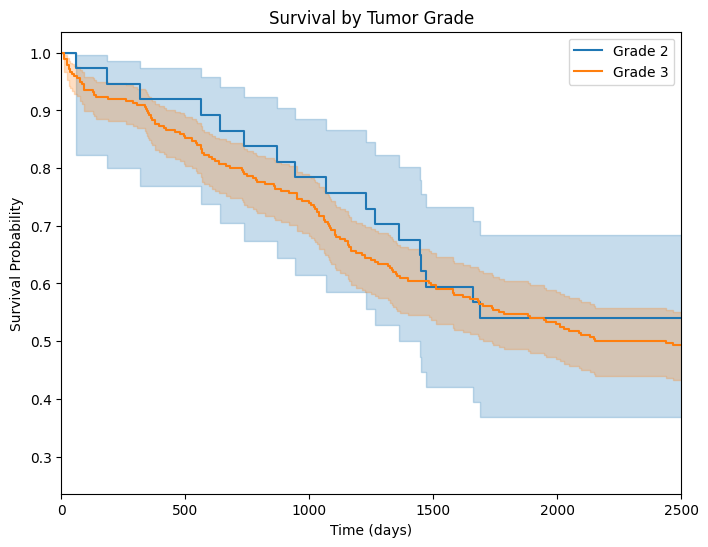

Log-rank test p-value (Grade 2 vs 3): 0.5221128795891518


In [ ]:
kmf = KaplanMeierFitter()
plt.figure(figsize=(8,6))

# Store survival times and events for each grade
grade_data = {}  # Dictionary to store data for each grade

for grade in sorted(df['tumor_grade_encoded'].unique()):
    mask = df['tumor_grade_encoded'] == grade
    # Drop rows with NaN in survival_time or event for the current grade
    df_subset = df[mask].dropna(subset=['survival_time', 'event'])
    kmf.fit(df_subset['survival_time'], df_subset['event'], label=f'Grade {int(grade)}')
    kmf.plot_survival_function()

    # Store survival data for log-rank test
    grade_data[grade] = (df_subset['survival_time'], df_subset['event'])

plt.title('Survival by Tumor Grade')
plt.xlabel('Time (days)')
plt.ylabel('Survival Probability')
plt.legend()

# Limit x-axis to 2500 days
plt.xlim(0, 2500)  # Changed from 3000 to 2500

plt.show()

# Log-rank test between Grade 2 and Grade 3 (example)
if 2.0 in grade_data and 3.0 in grade_data:
    # Get data for grades 2 and 3
    durations_A, event_observed_A = grade_data[2.0]
    durations_B, event_observed_B = grade_data[3.0]

    # Ensure both groups have the same number of observations for logrank_test
    min_len = min(len(durations_A), len(durations_B), len(event_observed_A), len(event_observed_B))
    durations_A = durations_A[:min_len]
    durations_B = durations_B[:min_len]
    event_observed_A = event_observed_A[:min_len]
    event_observed_B = event_observed_B[:min_len]

    results = logrank_test(durations_A, durations_B, event_observed_A, event_observed_B)
    print('Log-rank test p-value (Grade 2 vs 3):', results.p_value)

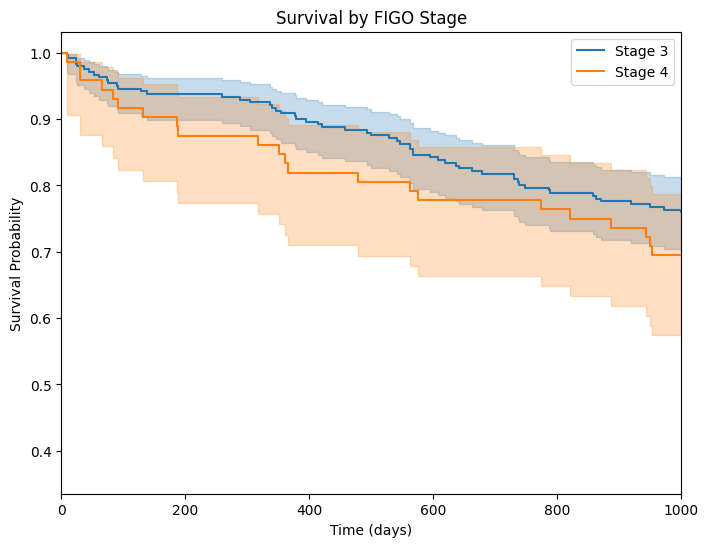

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test

plt.figure(figsize=(8, 6))

# Store survival times and events for each stage
stage_data = {}

for stage in sorted(df['figo_stage_encoded'].unique()):
    mask = df['figo_stage_encoded'] == stage
    subset_df = df[mask].dropna(subset=['survival_time', 'event'])

    if not subset_df.empty:
        kmf.fit(subset_df['survival_time'], subset_df['event'], label=f'Stage {int(stage)}')
        kmf.plot_survival_function()

        # Store survival data for log-rank test
        stage_data[stage] = (subset_df['survival_time'], subset_df['event'])

plt.title('Survival by FIGO Stage')
plt.xlabel('Time (days)')
plt.ylabel('Survival Probability')
plt.legend()

# Limit x-axis to 1000 days
plt.xlim(0, 1000)  # This line sets the x-axis limits

# Perform log-rank test (example: Stage 2 vs Stage 3)
if 2.0 in stage_data and 3.0 in stage_data:
    # Get data for stages 2 and 3
    durations_A, event_observed_A = stage_data[2.0]
    durations_B, event_observed_B = stage_data[3.0]

    # Ensure both groups have the same number of observations for logrank_test
    min_len = min(len(durations_A), len(durations_B), len(event_observed_A), len(event_observed_B))
    durations_A = durations_A[:min_len]
    durations_B = durations_B[:min_len]
    event_observed_A = event_observed_A[:min_len]
    event_observed_B = event_observed_B[:min_len]

    results = logrank_test(durations_A, durations_B, event_observed_A, event_observed_B)
    p_value = results.p_value
    plt.text(0.1, 0.1, f"Log-rank p-value (Stage 2 vs 3): {p_value:.3f}", transform=plt.gca().transAxes)

plt.show()

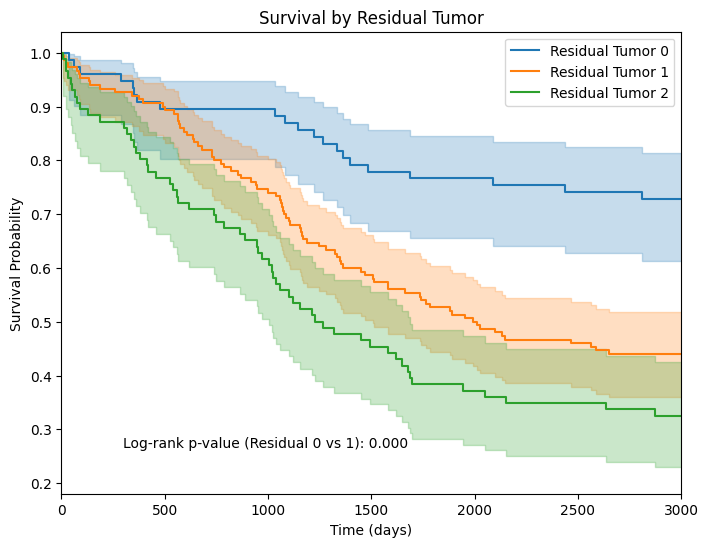

In [ ]:
plt.figure(figsize=(8,6))

# Store survival times and events for each residual tumor value
residual_data = {}

for rt in sorted(df['residual_tumor_encoded'].unique()):
    mask = df['residual_tumor_encoded'] == rt
    # Drop rows with NaN in survival_time or event for the current residual tumor value
    subset_df = df[mask].dropna(subset=['survival_time', 'event'])
    # Proceed only if the subset is not empty
    if not subset_df.empty:
        kmf.fit(subset_df['survival_time'], subset_df['event'], label=f'Residual Tumor {int(rt)}')
        kmf.plot_survival_function()

        # Store survival data for log-rank test
        residual_data[rt] = (subset_df['survival_time'], subset_df['event'])

plt.title('Survival by Residual Tumor')
plt.xlabel('Time (days)')
plt.ylabel('Survival Probability')
plt.legend()

# Limit x-axis to 3000 days
plt.xlim(0, 3000)  # This line sets the x-axis limits


# Perform log-rank test (example: Residual Tumor 0 vs Residual Tumor 1)
if 0.0 in residual_data and 1.0 in residual_data:
    # Get data for residual tumors 0 and 1
    durations_A, event_observed_A = residual_data[0.0]
    durations_B, event_observed_B = residual_data[1.0]

    # Ensure both groups have the same number of observations for logrank_test
    min_len = min(len(durations_A), len(durations_B), len(event_observed_A), len(event_observed_B))
    durations_A = durations_A[:min_len]
    durations_B = durations_B[:min_len]
    event_observed_A = event_observed_A[:min_len]
    event_observed_B = event_observed_B[:min_len]

    results = logrank_test(durations_A, durations_B, event_observed_A, event_observed_B)
    p_value = results.p_value
    plt.text(0.1, 0.1, f"Log-rank p-value (Residual 0 vs 1): {p_value:.3f}", transform=plt.gca().transAxes)

plt.show()

In [ ]:
# Select variables for the model
cph = CoxPHFitter()
covariates = ['tumor_grade_encoded', 'figo_stage_encoded', 'residual_tumor_encoded', 'chemo']

# Drop rows with any NaN values in the relevant columns before fitting
df_clean = df[['survival_time', 'event'] + covariates].dropna()

# Fit the model using the cleaned DataFrame
cph.fit(df_clean, duration_col='survival_time', event_col='event')
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 313 total observations, 145 right-censored observations>
             duration col = 'survival_time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 313
number of events observed = 168
   partial log-likelihood = -894.05
         time fit was run = 2025-05-16 07:10:21 UTC

---
                        coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                               
tumor_grade_encoded     0.08      1.08      0.23           -0.38            0.54                0.68                1.71
figo_stage_encoded      0.13      1.14      0.19           -0.24            0.51                0.79                1.66
residual_tumor_encoded  0.58      1.79      0.11            0.36            0.80                1.43                2.22
chemo                  -0.24      0.79      0.16           -0.55            0.08                0.58                1.08

                        cmp to     z      p  -log2(p)
covariate                                            
tumor_grade_encoded       0.00  0.34   0.73      0.45
figo_stage_encoded        0.00  0.71   0.48      1.06
residual_tumor_encoded    0.00  5.19 <0.005     22.19
chemo                     0.00 -1.49   0.14      2.87
---
Concordance = 0.63
Partial AIC = 1796.11
log-likelihood ratio test = 30.53 on 4 df
-log2(p) of ll-ratio test = 18.00